# Unit 5 — 01: Monitoring a Production ML Model

**What you will do:** Build a complete monitoring pipeline for a deployed iris classifier — logging predictions, simulating traffic with a distribution shift, computing rolling statistics, and firing alerts.

**Why it matters:** A model that was 95% accurate in testing can silently degrade in production. Monitoring is the only way to catch it.

**How to run:** Python 3.10+. Run cells in order. Restart kernel if you re-run from the top.

---

## Section 1 — What to Monitor

Four categories of production ML monitoring:

| Category | Examples | What it catches |
|---|---|---|
| **Infrastructure** | CPU %, memory usage, disk I/O | Server overload, OOM crashes |
| **Request metrics** | RPS, latency, HTTP error rate | Slow responses, service outages |
| **Prediction metrics** | Output class distribution, confidence scores | Silent failures, distribution shift |
| **Model quality** | Accuracy, F1 (when labels return) | Actual model degradation |

In this notebook we focus on **request metrics** and **prediction metrics** because they are available immediately — model quality labels often arrive days later.

## Section 2 — PredictionLogger

Every prediction is written to a JSON-lines log file. Each record contains: timestamp, input features, prediction, confidence, and latency.

In [1]:
import json
import time
import pathlib
from datetime import datetime, timedelta
from typing import List, Dict

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

LOG_PATH = pathlib.Path("/tmp/prediction_log.jsonl")
LOG_PATH.unlink(missing_ok=True)  # start fresh each run


class PredictionLogger:
    def __init__(self, log_path: pathlib.Path):
        self.log_path = log_path

    def log(self, features: List[float], prediction: int,
            confidence: float, latency_ms: float, timestamp: datetime) -> None:
        record = {
            "timestamp": timestamp.isoformat(),
            "features": features,
            "prediction": prediction,
            "confidence": round(confidence, 4),
            "latency_ms": round(latency_ms, 2),
        }
        with open(self.log_path, "a") as f:
            f.write(json.dumps(record) + "\n")

    def load_logs(self) -> List[Dict]:
        records = []
        with open(self.log_path) as f:
            for line in f:
                records.append(json.loads(line))
        return records


logger = PredictionLogger(LOG_PATH)
print("PredictionLogger ready. Log file:", LOG_PATH)

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


PredictionLogger ready. Log file: /tmp/prediction_log.jsonl


## Section 3 — Train a Model, Then Simulate 500 Requests

- Requests 1-400: normal iris features (no shift), latency ~30ms
- Requests 401-500: features multiplied by 1.5 (a sensor calibration change), AND the out-of-distribution inputs hit a slower path, pushing latency to ~120ms

We spread requests across a 24-hour window using datetime math so we can later compute per-hour statistics. Watch for two signals after the shift starts: the prediction class distribution changes, and p95 latency crosses the 100ms SLO.

In [2]:
rng = np.random.default_rng(42)

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)
print(f"Model trained. Test accuracy: {model.score(X_test, y_test):.3f}")

N_REQUESTS = 500
SHIFT_START = 400
window_start = datetime(2024, 1, 15, 0, 0, 0)
window_end   = datetime(2024, 1, 15, 23, 59, 59)
total_seconds = (window_end - window_start).total_seconds()

for i in range(N_REQUESTS):
    # pick a random sample from the test set
    idx = rng.integers(0, len(X_test))
    features = X_test[idx].copy()

    if i >= SHIFT_START:
        features = features * 1.5  # inject distribution shift
        # The shift also degrades serving latency: out-of-distribution inputs
        # take a slower path, so p95 latency climbs above the 100ms SLO.
        latency_ms = float(rng.normal(120, 25)) + (50 if rng.random() < 0.03 else 0)
    else:
        # normal traffic: latency ~30ms with occasional spikes
        latency_ms = float(rng.normal(30, 8)) + (50 if rng.random() < 0.03 else 0)
    latency_ms = max(5.0, latency_ms)

    proba = model.predict_proba(features.reshape(1, -1))[0]
    prediction = int(np.argmax(proba))
    confidence = float(np.max(proba))

    # spread evenly across 24 hours
    offset_s = (i / N_REQUESTS) * total_seconds
    ts = window_start + timedelta(seconds=offset_s)

    logger.log(features.tolist(), prediction, confidence, latency_ms, ts)

print(f"Logged {N_REQUESTS} requests ({SHIFT_START} normal, {N_REQUESTS - SHIFT_START} shifted)")

Model trained. Test accuracy: 1.000
Logged 500 requests (400 normal, 100 shifted)


## Section 4 — Rolling Statistics: Requests Per Hour, Latency, Class Distribution

Load the logs and compute:
- **Requests per hour** — traffic volume
- **Mean and p95 latency** — response time health
- **Prediction class distribution over time** — proxy for input shift

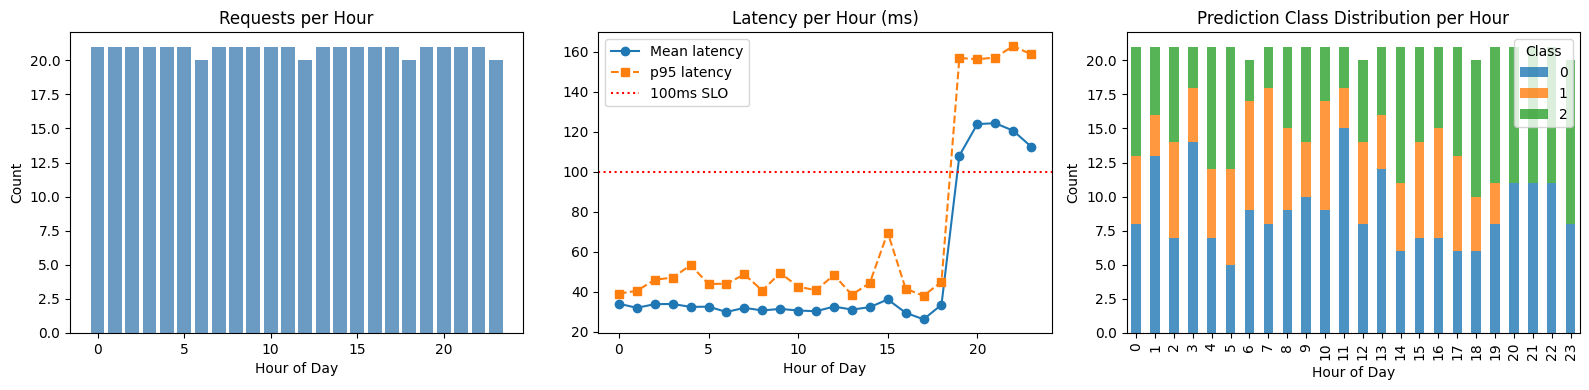

Notice how class distribution shifts after hour ~19 (the 400-request mark).


In [3]:
import pandas as pd

records = logger.load_logs()
df = pd.DataFrame(records)
df["timestamp"] = pd.to_datetime(df["timestamp"], format="ISO8601")
df["hour"] = df["timestamp"].dt.hour

# --- Requests per hour ---
rph = df.groupby("hour").size().rename("count")

# --- Latency stats per hour ---
lat_mean = df.groupby("hour")["latency_ms"].mean()
lat_p95  = df.groupby("hour")["latency_ms"].quantile(0.95)

# --- Prediction class distribution per hour ---
class_dist = df.groupby(["hour", "prediction"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(rph.index, rph.values, color="steelblue", alpha=0.8)
axes[0].set_title("Requests per Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Count")

axes[1].plot(lat_mean.index, lat_mean.values, label="Mean latency", marker="o")
axes[1].plot(lat_p95.index, lat_p95.values, label="p95 latency", marker="s", linestyle="--")
axes[1].axhline(100, color="red", linestyle=":", label="100ms SLO")
axes[1].set_title("Latency per Hour (ms)")
axes[1].set_xlabel("Hour of Day")
axes[1].legend()

class_dist.plot(ax=axes[2], kind="bar", stacked=True, alpha=0.8)
axes[2].set_title("Prediction Class Distribution per Hour")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Count")
axes[2].legend(title="Class")

plt.tight_layout()
plt.savefig("/tmp/monitoring_rolling_stats.png", dpi=72)
plt.show()
print("Notice how class distribution shifts after hour ~19 (the 400-request mark).")

## Section 5 — Confidence Score Tracking

When input data shifts away from the training distribution, the model's confidence typically drops. Plot rolling average confidence to catch this early — before ground-truth labels arrive.

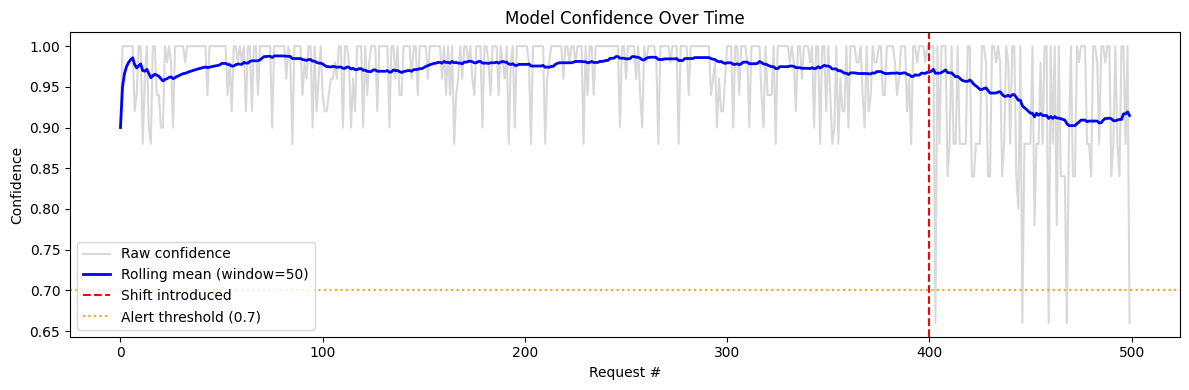

Confidence drops visibly after the shift — an early warning signal.


In [4]:
WINDOW = 50  # rolling window size

df_sorted = df.sort_values("timestamp").reset_index(drop=True)
df_sorted["rolling_confidence"] = df_sorted["confidence"].rolling(WINDOW, min_periods=1).mean()

plt.figure(figsize=(12, 4))
plt.plot(df_sorted.index, df_sorted["confidence"], alpha=0.3, color="gray", label="Raw confidence")
plt.plot(df_sorted.index, df_sorted["rolling_confidence"], color="blue",
         linewidth=2, label=f"Rolling mean (window={WINDOW})")
plt.axvline(SHIFT_START, color="red", linestyle="--", label="Shift introduced")
plt.axhline(0.7, color="orange", linestyle=":", label="Alert threshold (0.7)")
plt.title("Model Confidence Over Time")
plt.xlabel("Request #")
plt.ylabel("Confidence")
plt.legend()
plt.tight_layout()
plt.savefig("/tmp/monitoring_confidence.png", dpi=72)
plt.show()
print("Confidence drops visibly after the shift — an early warning signal.")

## Section 6 — Simple Alerting Function

An alerting function evaluates a rolling window of recent logs and fires if thresholds are breached. Because our injected shift also degraded latency, the **last 100 (shifted) requests should trip the p95-latency alert**, while the first 400 (normal) requests stay clean — exactly the behaviour you want from monitoring.

In [5]:
from typing import List, Dict, Optional


def check_alerts(
    recent_logs: List[Dict],
    confidence_threshold: float = 0.7,
    p95_latency_threshold_ms: float = 100.0,
) -> List[str]:
    """Return a list of alert strings for any breached thresholds."""
    alerts = []

    latencies = [r["latency_ms"] for r in recent_logs]
    confidences = [r["confidence"] for r in recent_logs]

    mean_confidence = float(np.mean(confidences))
    p95_latency = float(np.percentile(latencies, 95))

    if mean_confidence < confidence_threshold:
        alerts.append(
            f"ALERT: Low confidence — mean={mean_confidence:.3f} < threshold={confidence_threshold}"
        )
    if p95_latency > p95_latency_threshold_ms:
        alerts.append(
            f"ALERT: High p95 latency — {p95_latency:.1f}ms > threshold={p95_latency_threshold_ms}ms"
        )

    return alerts


# Evaluate on the last 100 requests (the shifted ones)
all_logs = logger.load_logs()
recent_100 = all_logs[-100:]

print("=== Alerts for last 100 requests (shifted data) ===")
alerts = check_alerts(recent_100)
if alerts:
    for a in alerts:
        print(a)
else:
    print("No alerts. All metrics within thresholds.")

print()

# Evaluate on the first 400 requests (normal)
first_400 = all_logs[:400]
print("=== Alerts for first 400 requests (normal data) ===")
alerts_normal = check_alerts(first_400)
if alerts_normal:
    for a in alerts_normal:
        print(a)
else:
    print("No alerts. All metrics within thresholds.")

=== Alerts for last 100 requests (shifted data) ===
ALERT: High p95 latency — 163.3ms > threshold=100.0ms

=== Alerts for first 400 requests (normal data) ===
No alerts. All metrics within thresholds.


## Summary

Four categories of production ML monitoring and what each catches:

1. **Infrastructure** (CPU, memory) — catches server overload before it causes outages
2. **Request metrics** (RPS, latency, error rate) — catches slow responses and service failures immediately
3. **Prediction metrics** (confidence, class distribution) — catches input distribution shift *without needing ground-truth labels*
4. **Model quality** (accuracy, F1) — confirms actual degradation but requires labels, which arrive with a delay

The key insight: **confidence drop is a leading indicator**. It fires before ground-truth labels arrive to confirm accuracy degradation.

## Self-Check (answer before scrolling back up)

1. **Why does mean latency hide problems that p95 catches?**  
   Mean latency is pulled down by the majority of fast requests, so occasional slow spikes (which impact 5% of users) are invisible. p95 directly measures the worst 5%.

2. **How can you monitor model quality without ground-truth labels?**  
   Track *prediction metrics* — confidence scores and output class distribution. If confidence drops or the class distribution shifts significantly, the model is likely encountering out-of-distribution data even before any labels come back.

3. **What does a sudden drop in average confidence likely indicate?**  
   The input feature distribution has changed (data drift). The model is receiving inputs far from its training distribution, so it cannot assign high probability to any single class.